In [38]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial
import bpmeth
from sympy import lambdify 
from sympy.abc import x, y, s


(0.0, 2.0)

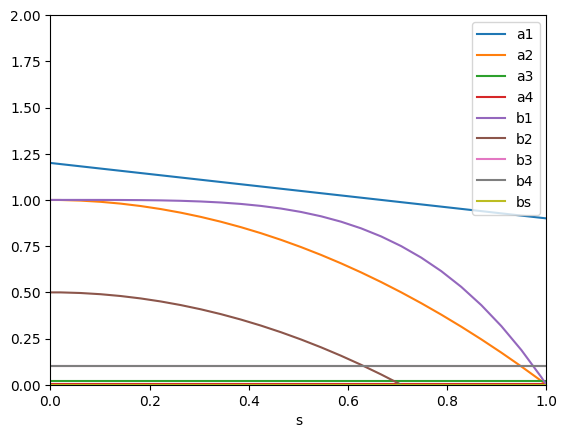

In [39]:
#start from multipole coeefficients a_n(s)=a1,a2,... and b_n(s)
# a_coeffs = [1,0.05,0.3,0]
# b_coeffs = [0.1,0.02,0.003,0]
a_coeffs = ["1.2-0.3*s", "1-s**2", 0.02, 0.002]
b_coeffs = ["1-s**4","0.5-s**2",0.1, 0.1]
# a_coeffs = ["3.4/(exp(s)+exp(-s))","-0.5*s**2+1.2",0.3,0.5]
# b_coeffs = ["2*exp(-s**2)",0.5,"1/(1+s**2)**1.5",0.05]
#get scalar potential
nphi=5
expansion=bpmeth.FieldExpansion(a=a_coeffs, b=b_coeffs, nphi=nphi)
expansion.plot_components()
plt.xlabel('s')
plt.xlim((0,1))
plt.ylim((0,2))

Scalar potential phi(x,y,s): -8.33333333333333e-5*x**4 - 0.00333333333333333*x**3 - x**2*(1 - s**2)/2 - x*(1.2 - 0.3*s) + 0.166583333333333*y**4 + y**3*(-72*s**2 - 11.4*x + 0.6)/36 + y**2*(-24*s**2 - 23.976*x**2 + 0.48*x + 24)/48 - y*(-6*s**4 + 0.1*x**3 + 0.3*x**2 + 6*x*(0.5 - s**2) + 6)/6
Scalar potential phi at (0.4,0.2,0.5): -0.6821790666666667


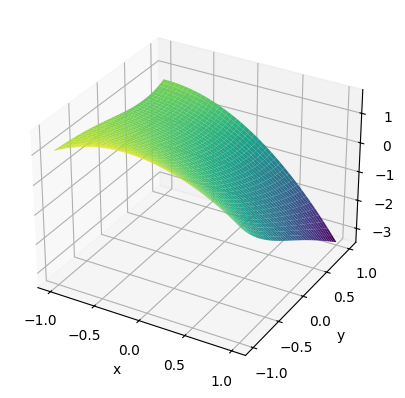

In [40]:
phi=expansion.get_phi()
print("Scalar potential phi(x,y,s):", phi)

XYS=(x,y,s)#symbolic expressions

phi_func = lambdify(XYS, phi, 'numpy')#from symbolic to numerical function
print("Scalar potential phi at (0.4,0.2,0.5):", phi_func(0.4,0.2,0.5))
#define x,y,s axes to convert the symbolic expression of phi into a numerical array
npoints=201
xa= np.linspace(-1,1,npoints) 
ya=np.linspace(-1,1,npoints)
sa=np.linspace(-1,1,npoints)
#make a 3d plot of phi as a function of x and y for a fixed s
X, Y = np.meshgrid(xa, ya)

P = phi_func(X, Y, 0.)#s=0 is the middle  of the magnet
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, P, cmap='viridis')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('phi(x,y,s=0.5)')
plt.show()

In [41]:
# Get analytical B field functions
Bx_func, By_func, Bs_func = expansion.get_Bfield(lambdify=True)
#print("Bx:", Bx_func, "By:", By_func, "Bs:", Bs_func)#with lambdify=False
# Evaluate on grid
X,Y,S = np.meshgrid(xa, ya, sa, indexing='ij')
Bx_ana = Bx_func(X, Y, S)
By_ana = By_func(X, Y, S)
Bs_ana = Bs_func(X, Y, S)

In [42]:
print(X.shape)

(201, 201, 201)


Text(0.5, 0, 'x')

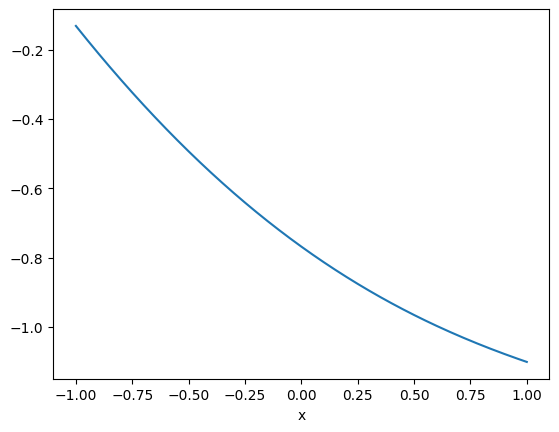

In [43]:
Ax, Ay, As = expansion.get_A(lambdify=True)
#print("Ax:", Ax, "Ay:", Ay, "As:", As)
Ax_ana = Ax(X, Y, S)
Ay_ana = Ay(X, Y, S)
As_ana = As(X, Y, S)

#plot As as a function of x for s=0 and y=0
plt.plot(xa, As_ana[:, 50, 10])
plt.xlabel('x')

(201, 201, 201) (201, 201, 201)
Max difference in Bx: 0.017825445833353548
Max relative difference in By: 0.15678385718852209
Max difference in Bs: 0.05956766666667135


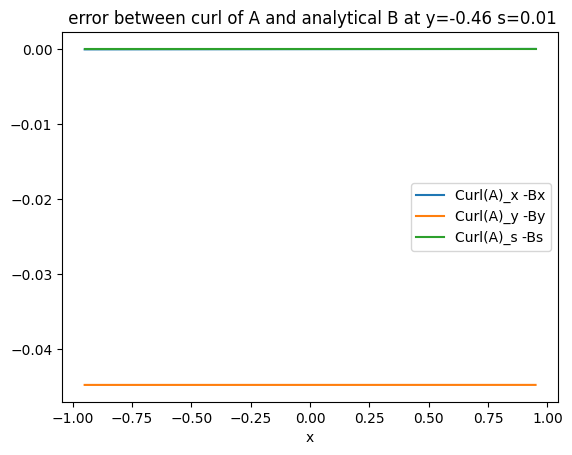

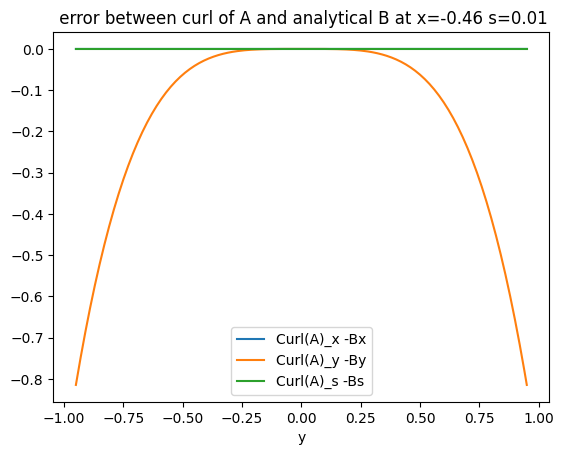

In [44]:
#then take the curl of A from finite differences and compare with the original B field
def curl_3d(Ax, Ay, Az, dx, dy, dz):
  
    # Compute partial derivatives
    dAx_dy = np.gradient(Ax, dy, axis=1)
    dAx_dz = np.gradient(Ax, dz, axis=2)
    dAy_dx = np.gradient(Ay, dx, axis=0)
    dAy_dz = np.gradient(Ay, dz, axis=2)
    dAz_dx = np.gradient(Az, dx, axis=0)
    dAz_dy = np.gradient(Az, dy, axis=1)
    
    # Curl components
    curl_x = dAz_dy - dAy_dz
    curl_y = dAx_dz - dAz_dx
    curl_z = dAy_dx - dAx_dy
    
    return curl_x, curl_y, curl_z

# Compute spacings
dx = xa[1] - xa[0]
dy = ya[1] - ya[0]
ds = sa[1] - sa[0]
# Compute curl
curl_Ax, curl_Ay, curl_As = curl_3d(Ax_ana, Ay_ana, As_ana, dx, dy, ds)
print(curl_Ax.shape, Bx_ana.shape)
# Compare with computed curl
print("Max difference in Bx:", np.max(np.abs(curl_Ax - Bx_ana)))
print("Max relative difference in By:", np.max(np.abs(curl_Ay - By_ana))/np.max(np.abs(By_ana)))
print("Max difference in Bs:", np.max(np.abs(curl_As - Bs_ana)))

truncatedx=xa[5:npoints-5]#to avoid boundary effects from finite differences
#truncateds=sa[5:npoints-5]#to avoid boundary effects from finite differences
#position=(45, 54,slice(5,npoints-5))#x=0, y=0, all s
position=( slice(5,npoints-5),54, 101)#all x, y=0, s=0.5

plt.plot(truncatedx, (curl_Ax[position]-Bx_ana[position]), label='Curl(A)_x -Bx')
plt.xlabel('x')
plt.title(' error between curl of A and analytical B at y='+str(round(sa[position[1]],2)) +" s="+str(round(sa[position[2]],2)))

plt.plot(truncatedx, (curl_Ay[position]-By_ana[position]), label='Curl(A)_y -By')
plt.plot(truncatedx, (curl_As[position]-Bs_ana[position]), label='Curl(A)_s -Bs')

#plt.ylim((np.min((curl_Ay[position]-By_ana[position])/By_ana[position]), np.max((curl_Ay[position]-By_ana[position])/By_ana[position])))
plt.legend()

plt.show()

truncatedy=xa[5:npoints-5]#to avoid boundary effects from finite differences
positiony=( 54,slice(5,npoints-5), 101)#all x, y=0, s=0.5

plt.plot(truncatedy, (curl_Ax[positiony]-Bx_ana[positiony]), label='Curl(A)_x -Bx')
plt.xlabel('y')
plt.title(' error between curl of A and analytical B at x='+str(round(sa[positiony[0]],2)) +" s="+str(round(sa[positiony[2]],2)))

plt.plot(truncatedy, (curl_Ay[positiony]-By_ana[positiony]), label='Curl(A)_y -By')
plt.plot(truncatedy, (curl_As[positiony]-Bs_ana[positiony]), label='Curl(A)_s -Bs')
#plt.ylim((np.min((curl_Ay[positiony]-By_ana[positiony])/By_ana[positiony]), np.max((curl_Ay[positiony]-By_ana[positiony])/By_ana[positiony])))
plt.legend()

plt.show()


When the a,b coefficients are polynomial the expansion needs at least nphi=order of the polynomial+2  to be complete. The fact that it is complete is made visible by the divergence of B, which is 0 only in that case.

4.0901134000000265
index = (np.int64(0), np.int64(200), np.int64(0))
x = -1.0
y = 1.0
s = -1.0
divB = 4.0901134000000265


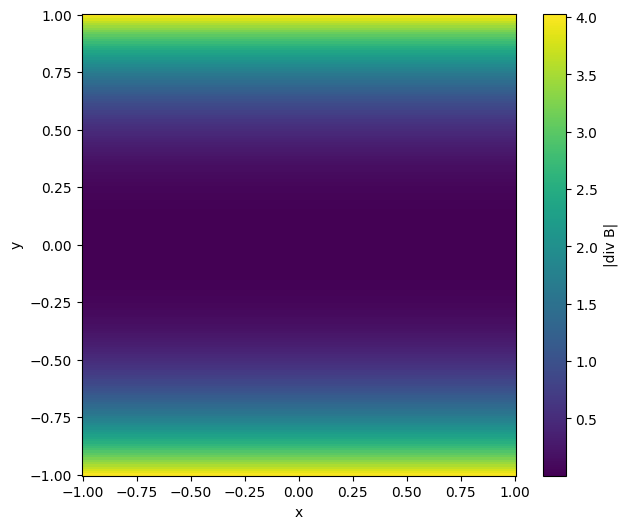

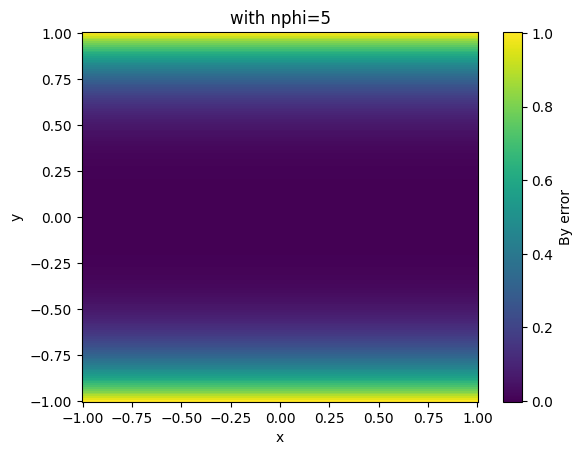

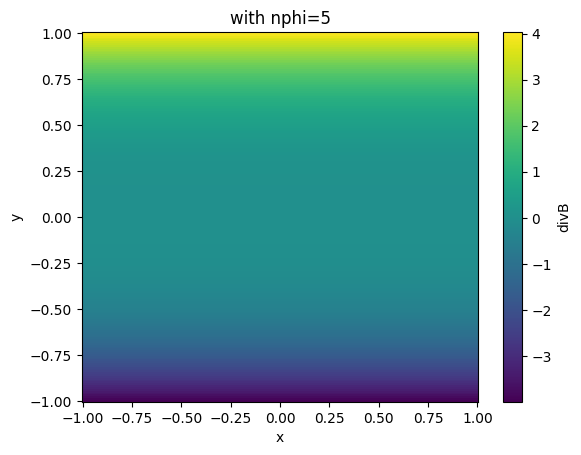

In [45]:
divB = (
    np.gradient(Bx_ana, xa, axis=0)
  + np.gradient(By_ana, ya, axis=1)
  + np.gradient(Bs_ana, sa, axis=2)
)
print(np.max(np.abs(divB)))
idx = np.unravel_index(np.argmax(np.abs(divB)), divB.shape)

print("index =", idx)
print("x =", xa[idx[0]])
print("y =", ya[idx[1]])
print("s =", sa[idx[2]])
print("divB =", divB[idx])

#print(np.max(np.abs(divB[10:-10, 10:-10, 10:-10])))
k = len(sa)//2

plt.figure(figsize=(7,6))
plt.pcolormesh(xa, ya, np.abs(divB[:, :, k]).T, shading='auto')
plt.colorbar(label='|div B|')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

errBy = -(curl_Ay - By_ana)

k = len(sa)//2

plt.pcolormesh(xa, ya, errBy[:, :, k].T, shading='auto')
plt.colorbar(label='By error')
plt.title('with nphi='+str(nphi))
plt.xlabel('x')
plt.ylabel('y')
plt.show()

plt.title('with nphi='+str(nphi))
plt.pcolormesh(xa, ya, divB[:, :, k].T, shading='auto')
plt.colorbar(label='divB')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

Local Harmonic analysis

In [47]:
datafieldmap = np.column_stack([
    X.ravel(),
    Y.ravel(),
    S.ravel(),
    curl_Ax.ravel(),
    curl_Ay.ravel(),
    curl_As.ravel()
])
curlfieldmap =bpmeth.fieldmaps.Fieldmap(datafieldmap)

rr, thetavec, fields = bpmeth.fieldmaps.Fieldmap.interp_cartesian_to_cylindrical(
    cart_fieldmap=curlfieldmap,
    x_1d=xa, y_1d=ya, s_1d=sa,
    rmin=0.05, rmax=0.7, nr=40, ntheta=256, ns=npoints
)
R, TH, S = np.meshgrid(rr, thetavec, sa, indexing='ij')
datacylcurl = np.column_stack([
    R.ravel(),
    TH.ravel(),
    S.ravel(),
    fields['Bx'].ravel(),
    fields['By'].ravel(),
    fields['Bs'].ravel(),
])
fieldmap_cyl = bpmeth.fieldmaps.Fieldmap.from_cylindrical(datacylcurl, field_components='cartesian')
# harmonic_analysis_at_s returns (an, bn)
(an_vals, bn_vals) = fieldmap_cyl.harmonic_analysis_at_s(s_index=(npoints+1)/2, rr=rr, ntheta=256, ns=npoints)
bn = bn_vals.real[:len(b_coeffs)]
an = an_vals.imag[:len(a_coeffs)]

print("recovered bn(0): ", bn)
print("Original bn(s): ", b_coeffs)
print("recovered an(0): ", an)
print("Original an(s): ", a_coeffs)

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 8120601 and the array at index 2 has size 2058240

In [ ]:
p=4#how many values to plot
#evaluate the symbolic expressions of the original coefficients to compare them with the recovered ones
b_ana = lambdify(s, b_coeffs, 'numpy')
a_ana = lambdify(s, a_coeffs, 'numpy')
# plt.plot(range(1,len(a_coeffs[:p])+1), np.abs(a_ana(s_fixed)[:p]-an[:p])/a_ana(s_fixed)[:p], 'o', label='a_n error from HA')
# plt.plot(range(1,len(b_coeffs[:p])+1), np.abs(b_ana(s_fixed)[:p]-bn[:p])/b_ana(s_fixed)[:p], 'o', label='b_n error from HA')
plt.plot(range(1,len(b_coeffs[:p])+1), np.abs(bn[:p]-b_coeffs[:p])/b_coeffs[:p], 'o', label='b_n error from HA')
plt.plot(range(1,len(a_coeffs[:p])+1), np.abs(an[:p]-a_coeffs[:p])/a_coeffs[:p], 'o', label='a_n error from HA')
plt.yscale('log')
plt.xlabel('Index')
plt.grid(True)
plt.ylabel('$|b_n - b_n^{orig}|/|b_n^{orig}|$')
plt.title('Relative error of multipole components reconstructed with HA at s=' + str(sa[int(len(sa)/2)]))
plt.legend()
plt.show()

Fourier Transform for the s-independent case

In [ ]:
#Since there is no s dependence in the original coefficients i can use fft
bnianfft=curlfieldmap.fft_at_s(spos=s_fixed, r=0.4, radius=0.04)
bnfft=bnianfft.real[:len(b_coeffs)]
print("bn recovered by Fourier transform: ",bnfft )
print("Original bn: ", b_coeffs)

HA along s

In [ ]:
svals, bnHA, errorbnHA = curlfieldmap.s_harmonics(order=len(b_coeffs), rmin=0.2, rmax=0.3,nr=10, radius=0.03)

In [ ]:
print("Original a_n(s=0): ", a_ana(s_fixed))
print("Original b_n(s=0): ", b_ana(s_fixed))

In [ ]:
plt.plot(svals, bnHA[:,0], label='recovered b1(s)')
plt.fill_between(svals, bnHA[:,0]-errorbnHA[:,0], bnHA[:,0]+errorbnHA[:,0], alpha=0.2)
plt.plot(svals, b_ana(svals)[0], label='original b1(s)')
plt.xlabel('s')
plt.title('b1(s) from s_harmonics')
plt.legend()
plt.show()

plt.plot(svals, bnHA[:,1], label='recovered b2(s)')
plt.fill_between(svals, bnHA[:,1]-errorbnHA[:,1], bnHA[:,1]+errorbnHA[:,1], alpha=0.2)
plt.xlabel('s')
plt.title('b2(s) from s_harmonics')
plt.plot(svals, b_ana(svals)[1], label='original b2(s)')
plt.legend()
plt.show()

In [ ]:
p=4#how many values to plot

#plt.plot(range(1,len(a_coeffs[:p])+1), np.abs(a_coeffs[:p]-an[:p])/a_coeffs[:p], 'o', label='a_n error from HA')
plt.yscale('log')
plt.xlabel('Index')
plt.title('Relative error of b multipole components reconstructed with H.A. at s=' + str(f"{s_fixed:.3f}"))
plt.plot(range(1,len(b_coeffs[:p])+1), np.abs(b_eva(s_fixed)[:p]-b_nnew[:p,s_indx])/b_eva(s_fixed)[:p], 'o', label='relative error on b_n from FD' )
plt.plot(range(1,len(a_coeffs[:p])+1), np.abs(a_eva(s_fixed)[:p]-a_nnew[:p,s_indx])/a_eva(s_fixed)[:p], 'o', label='relative error on a_n from FD' )
plt.legend()
plt.ylabel('$|b_n - b_n^{orig}|/|b_n^{orig}|$')
plt.grid(True)
plt.show()

In [ ]:
degree = 5
import sympy as sp
b_nfit = []

for j in range(bnHA.shape[1]):
    coeffs = np.polyfit(svals, bnHA[:,j], deg=degree)
    poly_expr = sum(sp.Float(c) * s**(degree - i) for i, c in enumerate(coeffs))
    poly_expr = sp.expand(poly_expr)
    b_nfit.append(str(poly_expr))

# a_nfit=[]

# for j in range(anHA.shape[0]):
#     coeffs = np.polyfit(sa, anHA[j, :], deg=degree)
#     poly_expr = sum(sp.Float(c) * s**(degree - i) for i, c in enumerate(coeffs))
#     poly_expr = sp.expand(poly_expr)
#     a_nfit.append(str(poly_expr))

print("fit on reconstruction", b_nfit)
print("original",b_coeffs)
plt.plot(sa, 1-sa**4, label="symbolic original b1")
plt.plot(sa, bnHA[:,0], label='recovered b1')
plt.legend()


In [ ]:
reconstruction=bpmeth.FieldExpansion(a=a_coeffs, b=b_nfit) #here I'm CHEATING because i don't recover a(s) from HA
#make a fieldmap of this reconstruction
Bx_rec, By_rec, Bs_rec = reconstruction.get_Bfield(lambdify=True)
Bx_rec_mesh = Bx_rec(X, Y, S)
By_rec_mesh = By_rec(X, Y, S)
Bs_rec_mesh = Bs_rec(X, Y, S)
reconfieldmap = np.column_stack([
    X.ravel(),
    Y.ravel(),
    S.ravel(),
    Bx_rec_mesh.ravel(),
    By_rec_mesh.ravel(),
    Bs_rec_mesh.ravel()
])
#print("Data shape (N, 6):", datafieldmap.shape)
fm_rec = bpmeth.fieldmaps.Fieldmap(reconfieldmap)
fm_rec.plot()


In [ ]:
#make a fieldmap from the original expansion
originaldatafieldmap = np.column_stack([
    X.ravel(),
    Y.ravel(),
    S.ravel(),
    Bx_ana.ravel(),
    By_ana.ravel(),
    Bs_ana.ravel()
])
fm = bpmeth.fieldmaps.Fieldmap(originaldatafieldmap)
fm.plot()

In [ ]:
#make a fieldmap of the difference between the reconstruction and the original
resx=Bx_rec_mesh-Bx_ana
resy=By_rec_mesh-By_ana
ress=Bs_rec_mesh-Bs_ana
residualfieldmap = np.column_stack([
    X.ravel(),
    Y.ravel(),
    S.ravel(),
    resx.ravel(),
    resy.ravel(),
    ress.ravel()
])
#print("Data shape (N, 6):", datafieldmap.shape)
fmresidual = bpmeth.fieldmaps.Fieldmap(residualfieldmap)
fmresidual.plot()